In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [5]:
df = pd.read_csv(r'C:\Users\jhans\OneDrive\ドキュメント\apex\data\processed\covid_cleaned.csv')

df.head()

,date_reported,country_code,country,continent,who_region,new_cases,cumulative_cases,new_deaths,cumulative_deaths
0,2020-01-05,AF,Afghanistan,Asia,EMRO,0,0,0,0
1,2020-01-12,AF,Afghanistan,Asia,EMRO,0,0,0,0
2,2020-01-19,AF,Afghanistan,Asia,EMRO,0,0,0,0
3,2020-01-26,AF,Afghanistan,Asia,EMRO,0,0,0,0
4,2020-02-02,AF,Afghanistan,Asia,EMRO,0,0,0,0


In [7]:
df.describe()

,new_cases,cumulative_cases,new_deaths,cumulative_deaths
count,5.856000e+04,5.856000e+04,58560.000000,5.856000e+04
mean,1.325372e+04,1.810312e+06,120.582821,2.012550e+04
std,2.212564e+05,7.851277e+06,805.691725,8.220948e+04
min,-6.507900e+04,0.000000e+00,-3432.000000,0.000000e+00
25%,0.000000e+00,4.402750e+03,0.000000,2.900000e+01
50%,4.400000e+01,4.682750e+04,0.000000,5.845000e+02
75%,1.201000e+03,5.351678e+05,12.000000,7.118000e+03
max,4.047548e+07,1.034368e+08,47687.000000,1.197213e+06


In [9]:
print("Mean Cases:", df["new_cases"].mean())
print("Median Cases:", df["new_cases"].median())
print("Mode Cases:", df["new_cases"].mode()[0])

print("Mean Deaths:", df["new_deaths"].mean())
print("Median Deaths:", df["new_deaths"].median())

Mean Cases: 13253.719518442624
Median Cases: 44.0
Mode Cases: 0
Mean Deaths: 120.58282103825137
Median Deaths: 0.0


In [11]:
print(df["new_cases"].std())
print(df["new_cases"].var())

print(df["new_deaths"].std())
print(df["new_deaths"].var())

221256.38694535074
48954388764.11077
805.6917254842737
649139.1565138261


In [13]:
corr = df[[
    "new_cases",
    "cumulative_cases",
    "new_deaths",
    "cumulative_deaths"
]].corr()

corr

,new_cases,cumulative_cases,new_deaths,cumulative_deaths
new_cases,1.000000,0.162430,0.294423,0.122155
cumulative_cases,0.162430,1.000000,0.234503,0.792750
new_deaths,0.294423,0.234503,1.000000,0.342313
cumulative_deaths,0.122155,0.792750,0.342313,1.000000


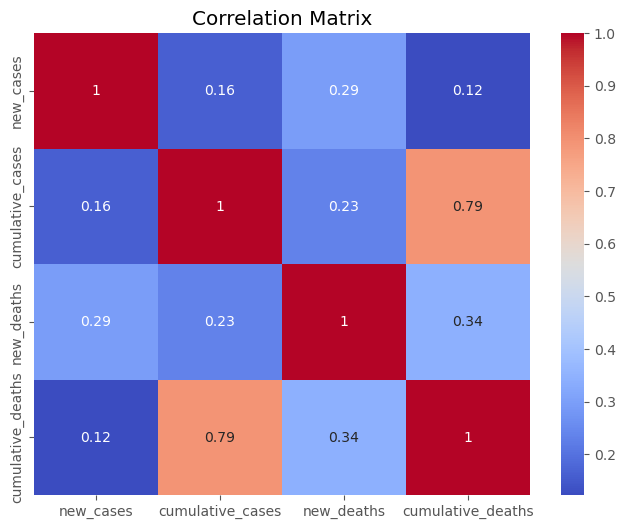

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

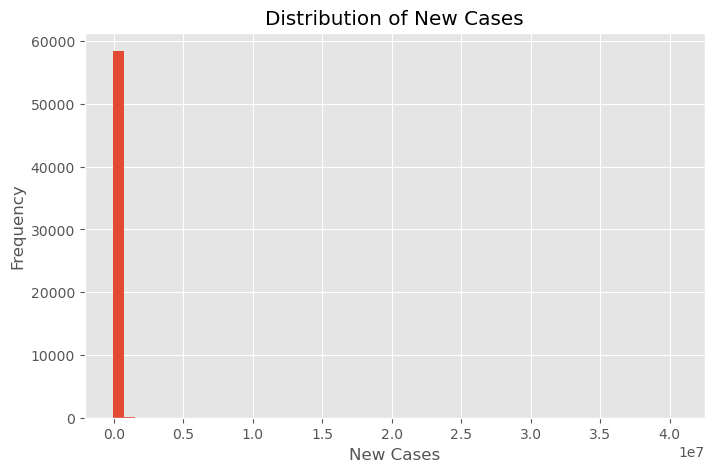

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df["new_cases"], bins=50)

plt.title("Distribution of New Cases")
plt.xlabel("New Cases")
plt.ylabel("Frequency")

plt.show()

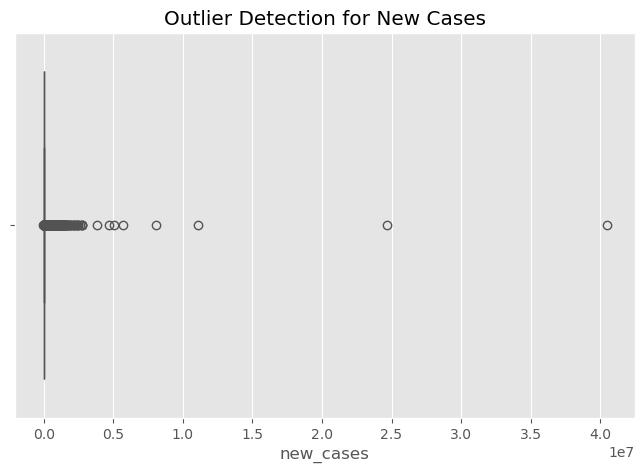

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["new_cases"])

plt.title("Outlier Detection for New Cases")

plt.show()

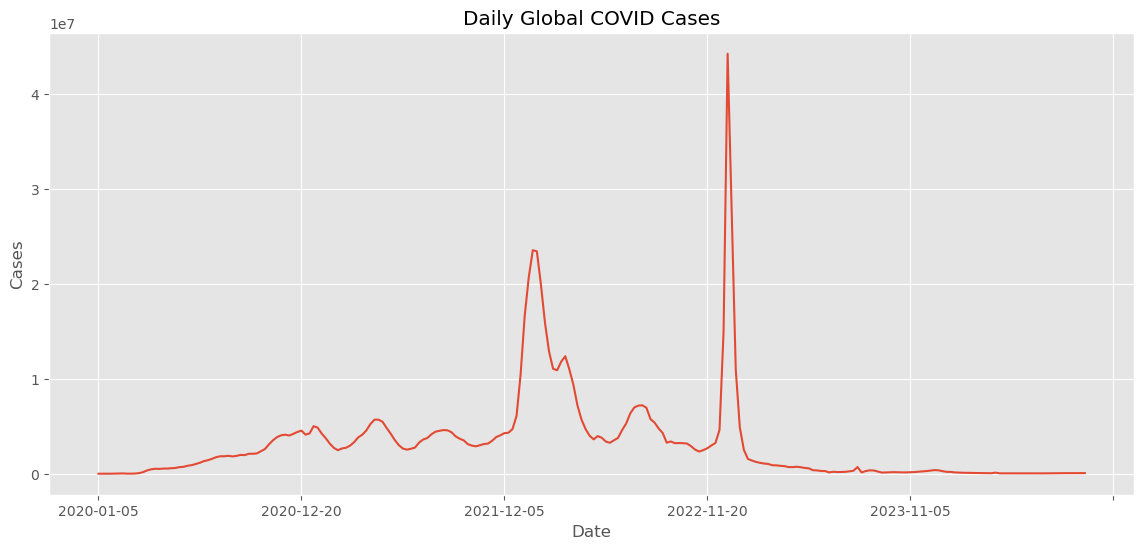

In [21]:
daily = df.groupby("date_reported")["new_cases"].sum()

plt.figure(figsize=(14,6))

daily.plot()

plt.title("Daily Global COVID Cases")

plt.xlabel("Date")
plt.ylabel("Cases")

plt.show()

In [23]:
df["date_reported"] = pd.to_datetime(df["date_reported"])

df["month"] = df["date_reported"].dt.month_name()

monthly = df.groupby("month")["new_cases"].sum()

monthly

month
April         52375225
August        56085307
December     105316867
February      76057206
January      165081766
July          53800463
June          31014348
March         63547208
May           47680339
November      45395870
October       41089793
September     38693423
Name: new_cases, dtype: int64

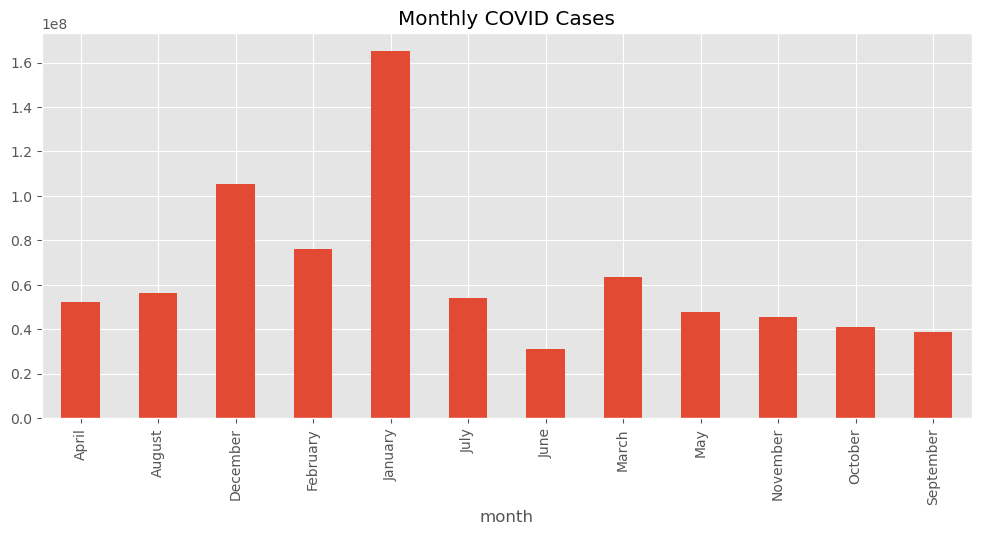

In [25]:
monthly.plot(kind="bar", figsize=(12,5))

plt.title("Monthly COVID Cases")

plt.show()

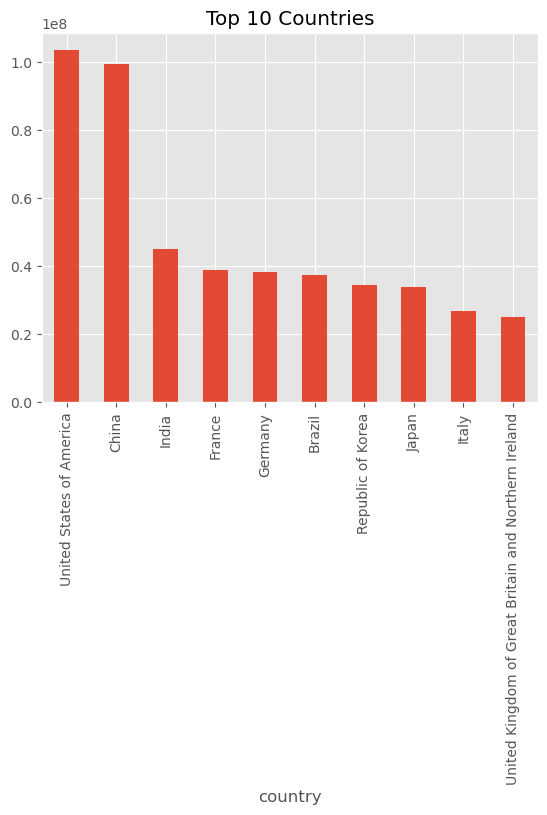

In [27]:
top = df.groupby("country")["cumulative_cases"].max().sort_values(ascending=False).head(10)

top.plot(kind="bar")

plt.title("Top 10 Countries")

plt.show()